# IAM Handwriting Recognition Benchmark Analysis

## Executive Summary

**Dataset:** IAM Mini - Handwriting Recognition  
**Total Samples:** 500 handwritten text images per phase  
**Task:** Optical Character Recognition (OCR) of cursive and print handwriting  
**Evaluation Metrics:** CER (Character Error Rate), WER (Word Error Rate), Cosine Similarity

## Benchmark Structure

### Phase Pa: OCR Baseline (Pure OCR Models)
- **Models:** Azure Document Intelligence, Mistral Document AI
- **Approach:** Direct OCR on handwritten text
- **Purpose:** Establish baseline OCR performance for handwriting recognition

### Phase Pb: VLM Baseline (Generic Prompting)
- **Models:** GPT-5-mini, GPT-5-nano, Claude Sonnet  
- **Prompt:** Generic text extraction (no handwriting context)
- **Purpose:** Evaluate general-purpose VLM capabilities for handwriting OCR

### Phase Pc: VLM with Task-Aware Prompting
- **Models:** GPT-5-mini, GPT-5-nano, Claude Sonnet
- **Prompt:** Handwriting-specific instructions
- **Purpose:** Evaluate impact of task-aware prompting on handwriting recognition

## Key Metrics

- **CER (Character Error Rate):** Edit distance at character level (lower is better, 0.0 = perfect)
- **WER (Word Error Rate):** Edit distance at word level (lower is better, 0.0 = perfect)
- **Cosine Similarity:** Semantic similarity using embeddings (higher is better, 1.0 = identical)

## Analysis Focus Areas

1. **OCR vs VLM:** Do vision language models outperform specialized OCR for handwriting?
2. **Prompting Impact:** How much does task-aware prompting improve VLM performance?
3. **Writing Style:** Cursive vs print handwriting recognition challenges
4. **Model Comparison:** Trade-offs between speed and accuracy across models
5. **Error Patterns:** Character-level vs word-level error analysis

## To Run This Analysis

1. Ensure consolidated data exists in `../../2_clean/IAM_mini/`
2. This notebook will load Pa, Pb, Pc results and generate:
   - Character and word error rate calculations
   - Semantic similarity analysis
   - Model comparison visualizations
   - Sample-level analysis (easiest/hardest samples)
   - Detailed error analysis

## 1. Imports and Metadata

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import sys
from pathlib import Path
from typing import List, Dict, Optional, Tuple
import warnings
warnings.filterwarnings('ignore')

# Progress bar for long operations
from tqdm.notebook import tqdm

# Add parent directory to path for imports
sys.path.insert(0, str(Path.cwd().parent.parent.parent))

# Import evaluation metrics
from ocr_vs_vlm.metrics.evaluation_metrics import (
    calculate_cer,
    calculate_wer,
    compute_anls,
    compute_exact_match,
    compute_ground_truth_in_prediction
)

# Import embedding cache manager for efficient cosine similarity computation
from ocr_vs_vlm.metrics.embedding_cache import EmbeddingCacheManager

# Import model ordering configuration for consistent display
sys.path.insert(0, str(Path.cwd().parent))
from utils.model_order import MODEL_ORDER, sort_models, get_model_display_name

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.width', 1000)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_palette('husl')

print("Libraries and evaluation metrics loaded successfully!")
print(f"Model display order: {', '.join(MODEL_ORDER)}")

Libraries and evaluation metrics loaded successfully!
Model display order: azure_intelligence, mistral_document_ai, gpt-5-nano, gpt-5-mini, claude_sonnet


## 2. Dataset Explorer

Load all phase files and explore the dataset structure.

In [ ]:
# Define paths
RESULTS_DIR = Path("../../2_clean/IAM_mini")

# Check available files
available_files = list(RESULTS_DIR.glob("*.csv"))
print("Available files:")
for f in sorted(available_files):
    print(f"  - {f.name}")

Available files:
  - Pa.csv
  - Pb.csv
  - Pc.csv
  - phase_1.csv
  - phase_2.csv
  - phase_3.csv


In [ ]:
# Dataset configuration
DATASET_NAME = "IAM_mini"

# Initialize embedding cache manager
# This will load any previously computed embeddings from 3_embeddings/
EMBEDDINGS_DIR = Path("../../3_embeddings")
embedding_manager = EmbeddingCacheManager(DATASET_NAME, EMBEDDINGS_DIR)

print(f"📁 Dataset: {DATASET_NAME}")
print(f"📂 Embeddings directory: {EMBEDDINGS_DIR.resolve()}")
if embedding_manager.cache:
    print(f"✅ Loaded cached embeddings for phases: {', '.join(embedding_manager.cache.keys())}")
else:
    print("⚠️ No cached embeddings found - will compute on first run and save for future use")

📁 Dataset: IAM_mini
📂 Embeddings directory: /Users/kenzabenkirane/Documents/GitHub/research-playground/ocr_vs_vlm/results/3_embeddings
✅ Loaded cached embeddings for phases: Pb, Pc, Pa


In [ ]:
# Load results for each phase
phase_dfs = {}

for phase in ['Pa', 'Pb', 'Pc']:
    file_path = RESULTS_DIR / f"{phase}.csv"
    if file_path.exists():
        phase_dfs[phase] = pd.read_csv(file_path)
        print(f"{phase}: {phase_dfs[phase].shape[0]} samples, {phase_dfs[phase].shape[1]} columns")
    else:
        print(f"{phase}: Not available")

print(f"\nTotal phases loaded: {len(phase_dfs)}")

Pa: 500 samples, 13 columns
Pb: 500 samples, 17 columns
Pc: 500 samples, 17 columns

Total phases loaded: 3


In [ ]:
# Inspect column names for each phase
for phase, df in phase_dfs.items():
    print(f"\n{phase} columns:")
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    models = [col.replace('prediction_', '') for col in pred_cols]
    print(f"  Models: {', '.join(models)}")
    print(f"  Ground truth column: {'ground_truth' if 'ground_truth' in df.columns else 'NOT FOUND'}")
    print(f"  Total columns: {len(df.columns)}")


Pa columns:
  Models: azure_intelligence, mistral_document_ai
  Ground truth column: ground_truth
  Total columns: 13

Pb columns:
  Models: claude_sonnet, gpt-5-mini, gpt-5-nano
  Ground truth column: ground_truth
  Total columns: 17

Pc columns:
  Models: claude_sonnet, gpt-5-mini, gpt-5-nano
  Ground truth column: ground_truth
  Total columns: 17


### Dataset Statistics

In [ ]:
phase_to_display = 'Pa'

In [ ]:
# Show basic statistics

if phase_to_display in phase_dfs:
    print(f"\nBasic statistics for phase {phase_to_display}:")
    df_base = phase_dfs[phase_to_display]
    
    print("Dataset Statistics:")
    print(f"  Total samples: {len(df_base)}")
    
    if 'ground_truth' in df_base.columns:
        # Text length statistics
        text_lengths = df_base['ground_truth'].str.len()
        print(f"\nGround Truth Text Length:")
        print(f"  Mean: {text_lengths.mean():.1f} characters")
        print(f"  Median: {text_lengths.median():.1f} characters")
        print(f"  Min: {text_lengths.min()} characters")
        print(f"  Max: {text_lengths.max()} characters")
        
        # Word count statistics
        word_counts = df_base['ground_truth'].str.split().str.len()
        print(f"\nGround Truth Word Count:")
        print(f"  Mean: {word_counts.mean():.1f} words")
        print(f"  Median: {word_counts.median():.1f} words")
        print(f"  Min: {word_counts.min()} words")
        print(f"  Max: {word_counts.max()} words")


Basic statistics for phase Pa:
Dataset Statistics:
  Total samples: 500

Ground Truth Text Length:
  Mean: 377.1 characters
  Median: 376.0 characters
  Min: 96 characters
  Max: 625 characters

Ground Truth Word Count:
  Mean: 72.6 words
  Median: 72.0 words
  Min: 19 words
  Max: 116 words


### Sample Predictions Preview

Display 10 random predictions from 3 different models to get a qualitative sense of performance.

In [ ]:
# Get 10 random samples from Pa phase
if phase_to_display in phase_dfs:
    df_samples = phase_dfs[phase_to_display].sample(n=min(10, len(phase_dfs[phase_to_display])), random_state=42)
    
    # Get model names
    pred_cols = [col for col in df_samples.columns if col.startswith('prediction_')]
    models = [col.replace('prediction_', '') for col in pred_cols[:3]]  # First 3 models
    
    print("="*120)
    print("SAMPLE PREDICTIONS - Showing 10 random samples")
    print("="*120)
    
    for idx, row in df_samples.iterrows():
        print(f"\nSample: {row['sample_id']}")
        print(f"Ground Truth: \n{row['ground_truth']}")
        print("-" * 120)
        
        for model in models:
            pred_col = f'prediction_{model}'
            if pred_col in row:
                pred_text = str(row[pred_col])
                display_text = pred_text
                print(f"{model:30s}: \n{display_text}")
        print("=" * 120)

SAMPLE PREDICTIONS - Showing 10 random samples

Sample: iam_454_k07-063a
Ground Truth: 
He looked at her . Heard thrown back in a pool of hair ,
her blood-red lips parted and the beating of her
heart in the full throat . Her mouth did things he
thought no human being could stand without
dying , but he went on living in an ocean of
voluptuousness , that swelled and ebbed over him ,
under him , in him and through him ...
------------------------------------------------------------------------------------------------------------------------
azure_intelligence            : 
He looked at her. Head thrown back in a pool of hair, her blood-red lips parted and
the beating of her heart in the full throat. Her mouth did things he thought no human
being could stand without dying, but he went on living in an ocean of voluptuousness,
that swelled and ebbed over him, under him, in him and through him ...
mistral_document_ai           : 
He looked at her. Head thrown back in a pool of hair, her blood

## 3. Metrics Evaluation

Calculate CER, WER, and cosine similarity for all models across all samples.

In [ ]:
# Import for incremental saving
from ocr_vs_vlm.metrics.embedding_cache import save_embeddings_for_phase

# Function to calculate metrics for a single prediction (using embedding cache)
def calculate_sample_metrics(
    ground_truth: str, 
    prediction: str,
    phase: str,
    sample_id: str,
    model: str,
    emb_manager: EmbeddingCacheManager
) -> Dict[str, float]:
    """Calculate all metrics for a single sample with cached embeddings."""
    if pd.isna(prediction) or prediction == "":
        return {
            'cer': 1.0,
            'wer': 1.0,
            'cosine_similarity': 0.0,
            'ground_truth_in_prediction': 0.0,
        }
    
    # Use embedding manager for cosine similarity (with caching)
    cosine_sim = emb_manager.compute_cosine_similarity(
        phase=phase,
        ground_truth=ground_truth,
        prediction=str(prediction),
        sample_id=sample_id,
        model=model
    )
    
    return {
        'cer': calculate_cer(ground_truth, prediction),
        'wer': calculate_wer(ground_truth, prediction),
        'cosine_similarity': cosine_sim,
        'ground_truth_in_prediction': compute_ground_truth_in_prediction(str(prediction), [ground_truth]),
    }

# Calculate metrics for all phases and models
metrics_results = {}

for phase, df in phase_dfs.items():
    print(f"\n📊 Calculating metrics for {phase}...")
    
    # Get all prediction columns
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    phase_metrics = {}
    
    for pred_col in pred_cols:
        model = pred_col.replace('prediction_', '')
        print(f"   Processing model: {model}")
        
        # Calculate metrics for each sample with progress bar
        metrics_list = []
        for _, row in tqdm(df.iterrows(), total=len(df), desc=f"   {model}", leave=False):
            metrics = calculate_sample_metrics(
                ground_truth=row['ground_truth'],
                prediction=row[pred_col],
                phase=phase,
                sample_id=row['sample_id'],
                model=model,
                emb_manager=embedding_manager
            )
            metrics_list.append(metrics)
        
        # Aggregate metrics
        phase_metrics[model] = {
            'cer': np.mean([m['cer'] for m in metrics_list]),
            'wer': np.mean([m['wer'] for m in metrics_list]),
            'cosine_similarity': np.mean([m['cosine_similarity'] for m in metrics_list]),
            'cer_std': np.std([m['cer'] for m in metrics_list]),
            'wer_std': np.std([m['wer'] for m in metrics_list]),
            'cosine_similarity_std': np.std([m['cosine_similarity'] for m in metrics_list]),
            'ground_truth_in_prediction': np.mean([m['ground_truth_in_prediction'] for m in metrics_list]),
            'ground_truth_in_prediction_std': np.std([m['ground_truth_in_prediction'] for m in metrics_list])
        }
        
        print(f"   ✅ {model}: CER={phase_metrics[model]['cer']:.4f}, WER={phase_metrics[model]['wer']:.4f}, Cosine={phase_metrics[model]['cosine_similarity']:.4f}")
    
    metrics_results[phase] = phase_metrics
    
    # Save embeddings incrementally after each phase completes
    if phase in embedding_manager.modified_phases:
        print(f"   💾 Saving embeddings for {phase}...")
        saved_file = save_embeddings_for_phase(
            dataset_name=DATASET_NAME,
            phase=phase,
            embeddings_dict=embedding_manager.cache[phase],
            embeddings_base_dir=EMBEDDINGS_DIR
        )
        print(f"   ✅ Saved: {saved_file.name}")

# Print cache statistics
embedding_manager.print_statistics()
print("\n✅ Metrics calculation complete!")


📊 Calculating metrics for Pa...
   Processing model: azure_intelligence


   azure_intelligence:   0%|          | 0/500 [00:00<?, ?it/s]

   ✅ azure_intelligence: CER=0.0894, WER=0.3011, Cosine=0.9457
   Processing model: mistral_document_ai


   mistral_document_ai:   0%|          | 0/500 [00:00<?, ?it/s]

   ✅ mistral_document_ai: CER=0.0866, WER=0.3047, Cosine=0.9260

📊 Calculating metrics for Pb...
   Processing model: claude_sonnet


...

   ✅ claude_sonnet: CER=0.2011, WER=0.2530, Cosine=0.8446
   Processing model: gpt-5-mini


   gpt-5-mini:   0%|          | 0/500 [00:00<?, ?it/s]

   ✅ gpt-5-mini: CER=0.0856, WER=0.1152, Cosine=0.9081
   Processing model: gpt-5-nano


   gpt-5-nano:   0%|          | 0/500 [00:00<?, ?it/s]

   ✅ gpt-5-nano: CER=0.0815, WER=0.1164, Cosine=0.9128

📊 Embedding Cache Statistics:
   Cache hits: 7988
   Cache misses: 0
   Hit rate: 100.0%

✅ Metrics calculation complete!


In [ ]:
# Create a summary DataFrame
summary_data = []

for phase, models in metrics_results.items():
    for model, metrics in models.items():
        summary_data.append({
            'Phase': phase,
            'Model': model,
            'CER': metrics['cer'],
            'WER': metrics['wer'],
            'Cosine Similarity': metrics['cosine_similarity'],
            'Ground Truth in Prediction': metrics['ground_truth_in_prediction']
        })

summary_df = pd.DataFrame(summary_data)

print("\nMetrics Summary:")
print("=" * 100)
display(summary_df.sort_values(['Phase', 'CER']))

# Best model per phase
print("\nBest Model per Phase (by CER):")
for phase in summary_df['Phase'].unique():
    phase_data = summary_df[summary_df['Phase'] == phase]
    best_model = phase_data.loc[phase_data['CER'].idxmin()]
    print(f"  {phase}: {best_model['Model']} (CER={best_model['CER']:.4f})")


Metrics Summary:


,Phase,Model,CER,WER,Cosine Similarity,Ground Truth in Prediction
1,Pa,mistral_document_ai,0.086612,0.304656,0.925955,0.000
0,Pa,azure_intelligence,0.089357,0.301115,0.945692,0.000
2,Pb,claude_sonnet,0.162604,0.223442,0.904628,0.008
4,Pb,gpt-5-nano,0.176064,0.243188,0.826287,0.000
3,Pb,gpt-5-mini,0.180321,0.245248,0.821987,0.000
7,Pc,gpt-5-nano,0.081485,0.116403,0.912823,0.012
6,Pc,gpt-5-mini,0.085551,0.115188,0.908134,0.018
5,Pc,claude_sonnet,0.201086,0.253041,0.844568,0.006



Best Model per Phase (by CER):
  Pa: mistral_document_ai (CER=0.0866)
  Pb: claude_sonnet (CER=0.1626)
  Pc: gpt-5-nano (CER=0.0815)


## 4. Overall View

Combined visualizations comparing all metrics across all models.

### Bar Chart Comparisons

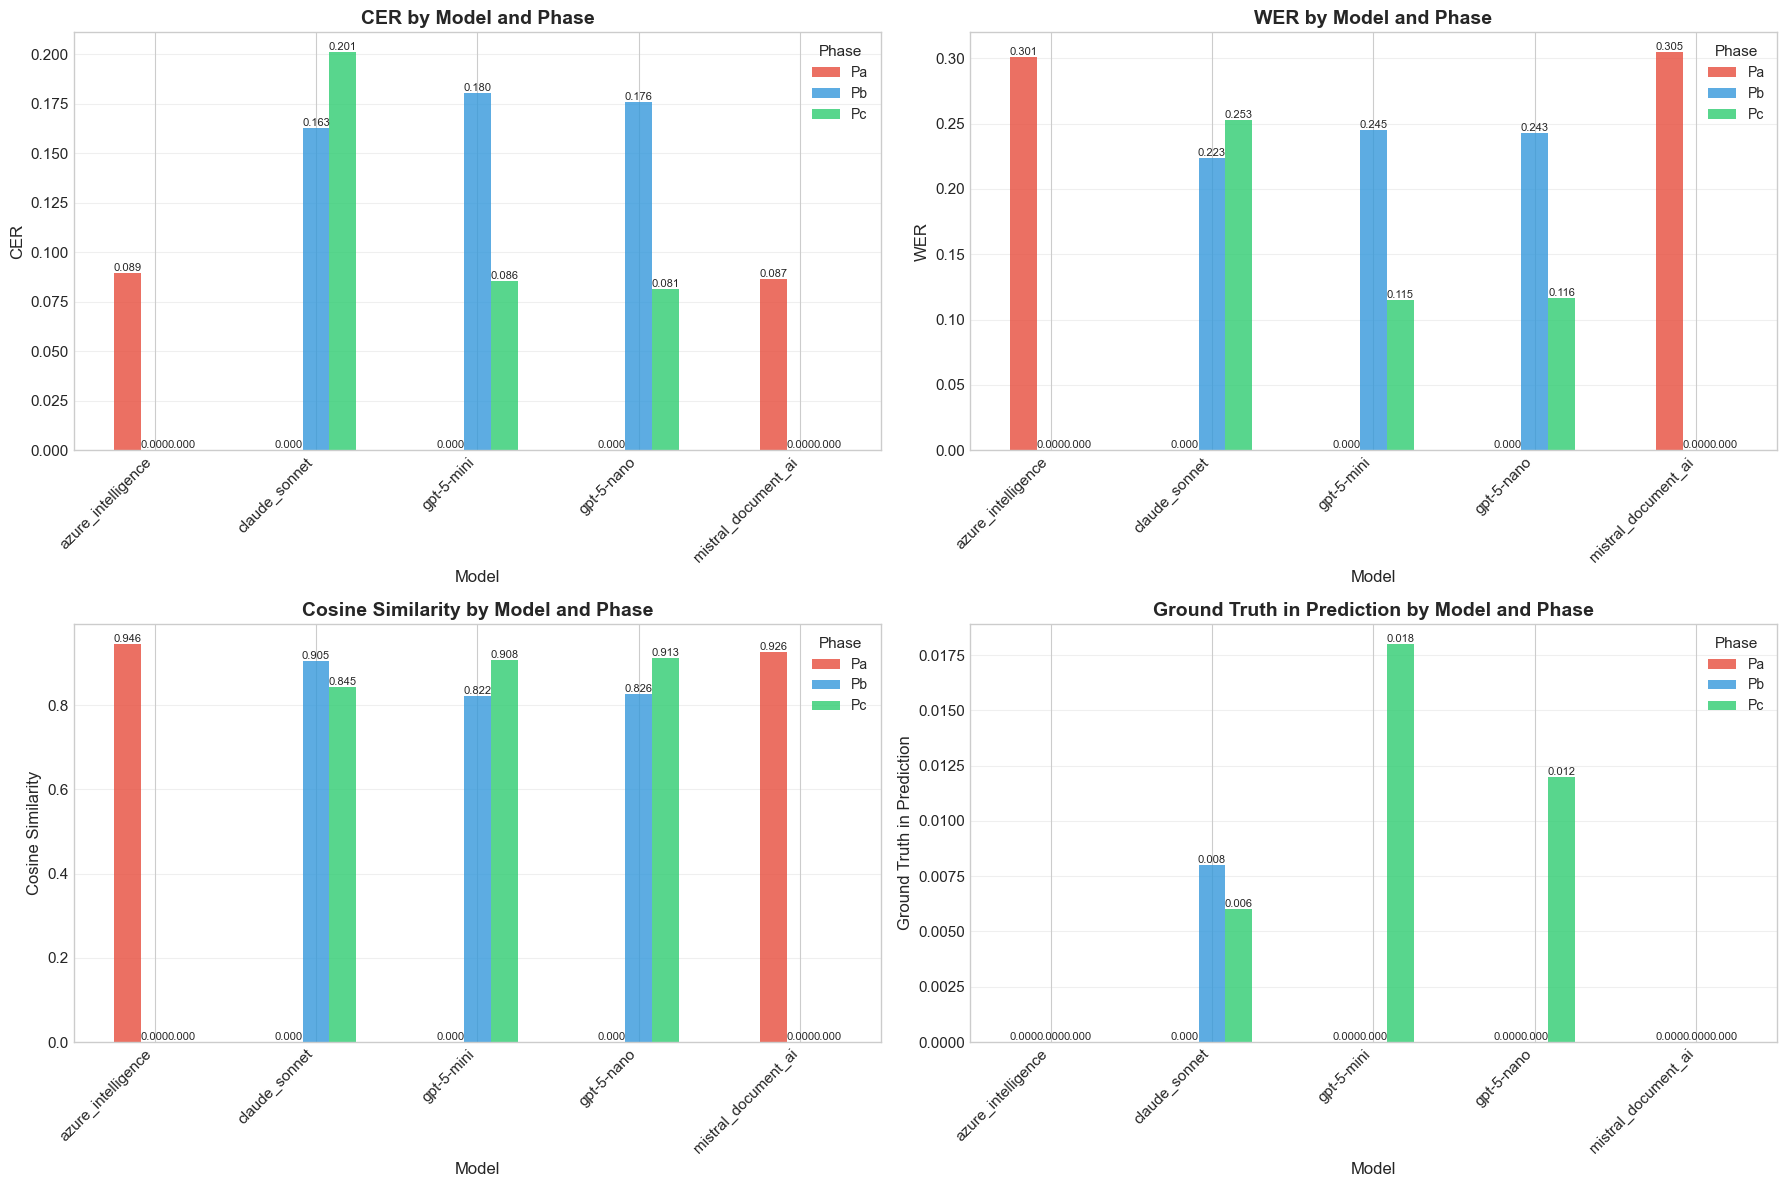

In [ ]:
# Bar charts for each metric
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

metrics_to_plot = ['CER', 'WER', 'Cosine Similarity', 'Ground Truth in Prediction']
colors = ['#ff6b6b', '#4ecdc4', '#45b7d1', '#f39c12']

for idx, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    ax = axes[idx]
    
    # Pivot data for grouped bar chart
    pivot_data = summary_df.pivot(index='Model', columns='Phase', values=metric)
    
    pivot_data.plot(kind='bar', ax=ax, color=['#e74c3c', '#3498db', '#2ecc71'], alpha=0.8)
    
    ax.set_title(f'{metric} by Model and Phase', fontsize=14, fontweight='bold')
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.legend(title='Phase', title_fontsize=11, fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    
    # Add value labels on bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=8)

plt.tight_layout()
plt.show()

### Box Plot Distribution Analysis

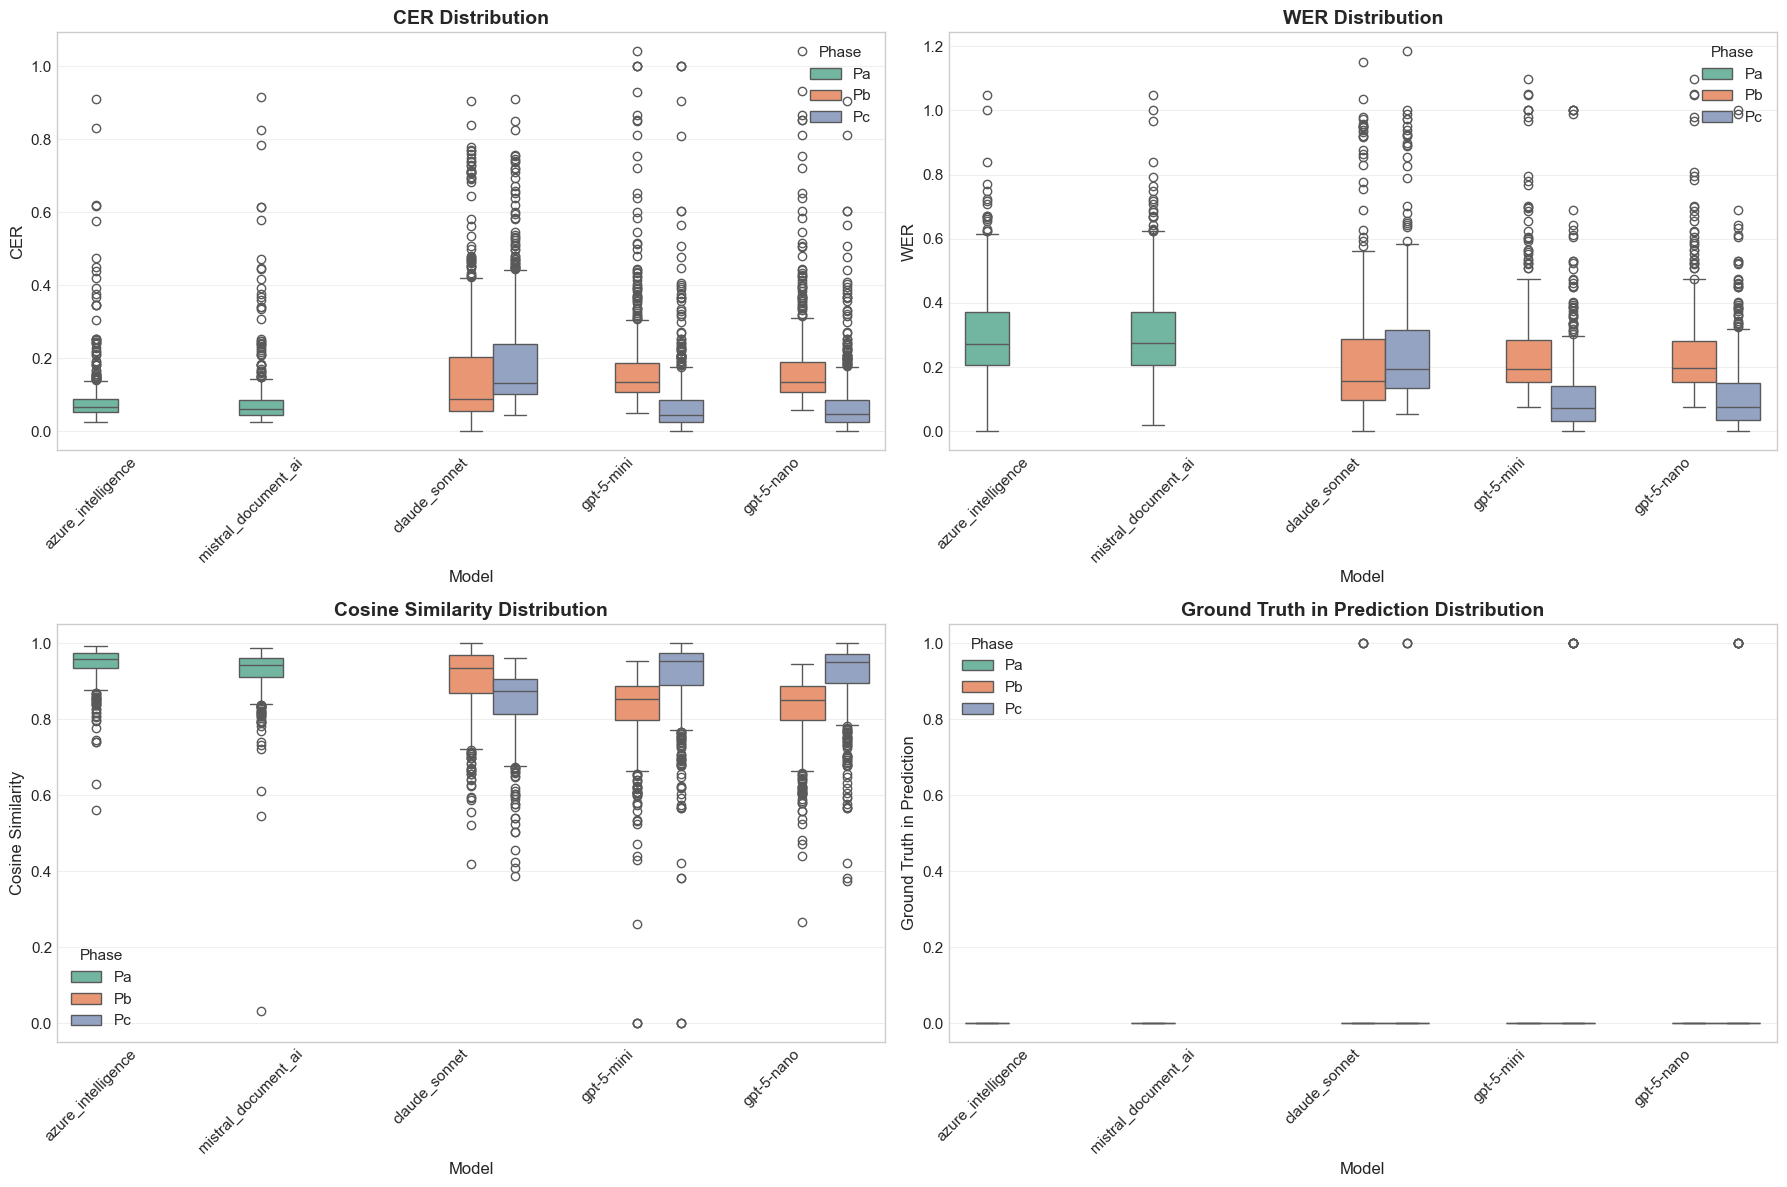

In [ ]:
# Calculate per-sample metrics for box plots
sample_metrics_data = []

for phase, df in phase_dfs.items():
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    for pred_col in pred_cols:
        model = pred_col.replace('prediction_', '')
        
        for _, row in df.iterrows():
            metrics = calculate_sample_metrics(row['ground_truth'], row[pred_col], phase, row['sample_id'], model, embedding_manager)
            
            sample_metrics_data.append({
                'Phase': phase,
                'Model': model,
                'CER': metrics['cer'],
                'WER': metrics['wer'],
                'Cosine Similarity': metrics['cosine_similarity'],
                'Ground Truth in Prediction': metrics['ground_truth_in_prediction']
            })

sample_metrics_df = pd.DataFrame(sample_metrics_data)

# Create box plots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for idx, metric in enumerate(['CER', 'WER', 'Cosine Similarity', 'Ground Truth in Prediction']):
    ax = axes[idx]
    
    # Create box plot
    sns.boxplot(data=sample_metrics_df, x='Model', y=metric, hue='Phase', ax=ax, palette='Set2')
    
    ax.set_title(f'{metric} Distribution', fontsize=14, fontweight='bold')
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Heatmap: Model vs Metric Performance

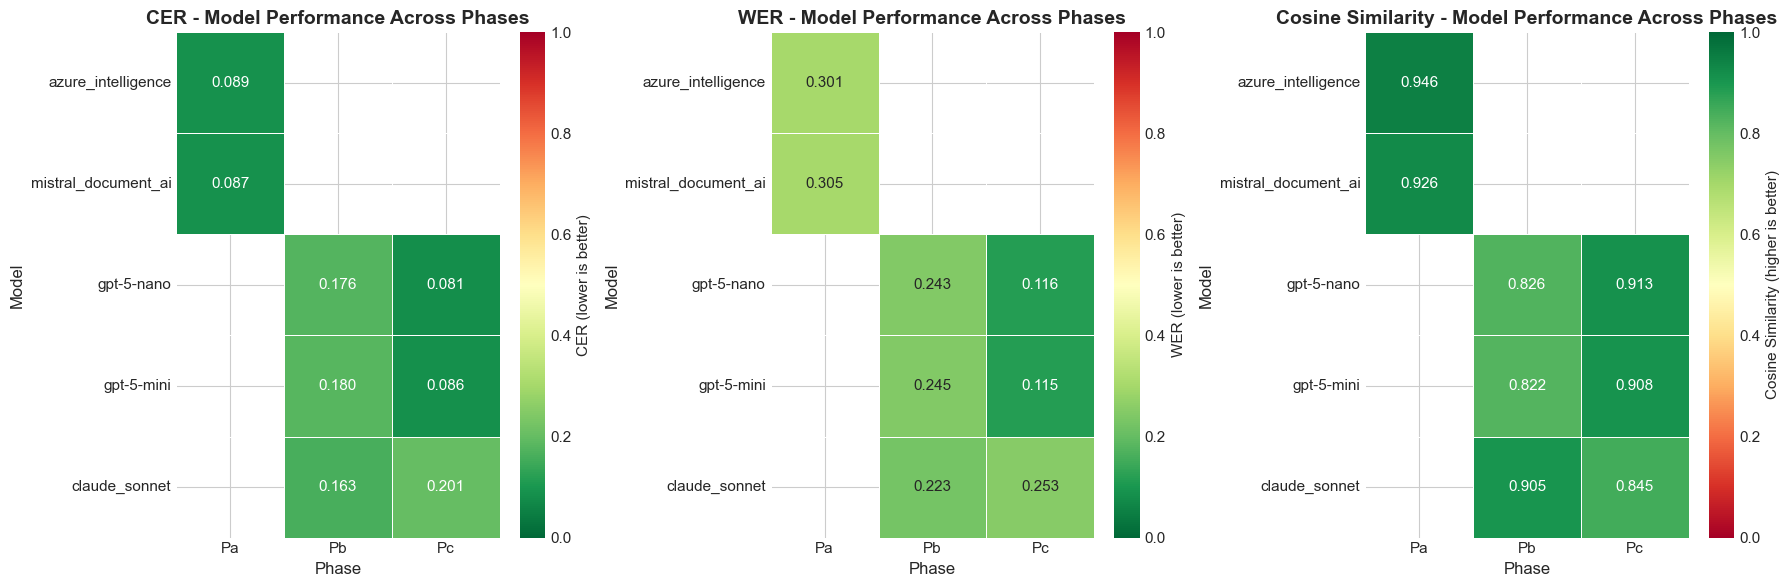

In [ ]:
# Create heatmaps for each metric
metrics_to_show = ['CER', 'WER', 'Cosine Similarity']
fig, axes = plt.subplots(1, len(metrics_to_show), figsize=(6 * len(metrics_to_show), 6))

if len(metrics_to_show) == 1:
    axes = [axes]

for idx, metric_name in enumerate(metrics_to_show):
    ax = axes[idx]
    
    # Create heatmap data: rows = models, columns = phases
    heatmap_data = []
    model_names = []
    phase_names = list(metrics_results.keys())
    
    # Get all unique models across all phases and sort them according to MODEL_ORDER
    all_models = set()
    for phase_models in metrics_results.values():
        all_models.update(phase_models.keys())
    all_models = sort_models(list(all_models))
    
    # Build heatmap data
    for model in all_models:
        row_data = []
        for phase in phase_names:
            if model in metrics_results[phase]:
                # Get the metric value based on metric_name
                if metric_name == 'CER':
                    value = metrics_results[phase][model]['cer']
                elif metric_name == 'WER':
                    value = metrics_results[phase][model]['wer']
                elif metric_name == 'Cosine Similarity':
                    value = metrics_results[phase][model]['cosine_similarity']
                else:
                    value = np.nan
                row_data.append(value)
            else:
                row_data.append(np.nan)
        
        heatmap_data.append(row_data)
        model_names.append(model)
    
    heatmap_df = pd.DataFrame(
        heatmap_data,
        index=model_names,
        columns=phase_names
    )
    
    # Set colormap and label based on metric type
    if metric_name in ['CER', 'WER']:
        # Lower is better for error rates - use reversed colormap (green for low, red for high)
        cmap = 'RdYlGn_r'
        cbar_label = f'{metric_name} (lower is better)'
    else:
        # Higher is better for Cosine Similarity - use normal colormap (green for high, red for low)
        cmap = 'RdYlGn'
        cbar_label = f'{metric_name} (higher is better)'
    
    sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap=cmap, 
                ax=ax, cbar_kws={'label': cbar_label}, 
                vmin=0, vmax=1, linewidths=0.5)
    
    ax.set_title(f'{metric_name} - Model Performance Across Phases', fontsize=14, fontweight='bold')
    ax.set_xlabel('Phase', fontsize=12)
    ax.set_ylabel('Model', fontsize=12)

plt.tight_layout()
plt.show()

### Scatter Plot: CER vs WER Correlation

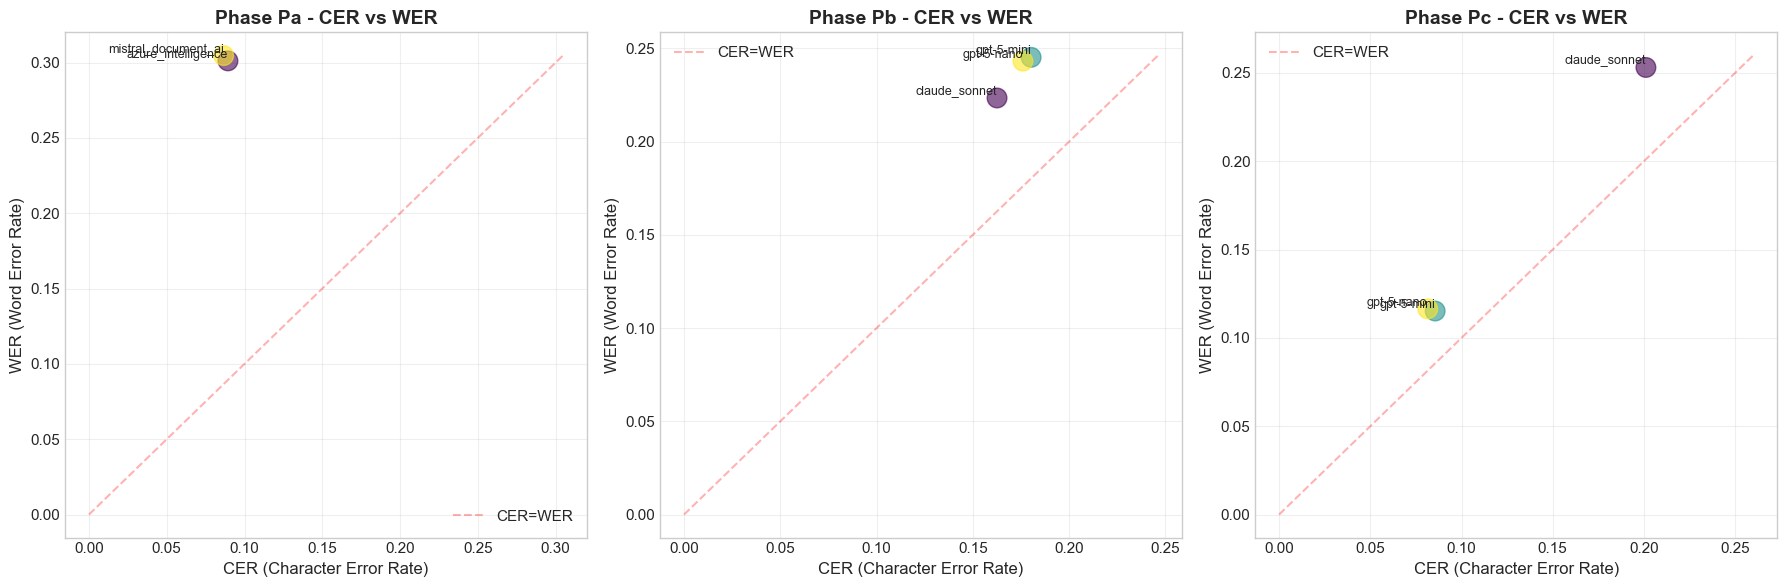

In [ ]:
# Scatter plot of CER vs WER for each phase
fig, axes = plt.subplots(1, len(metrics_results), figsize=(6 * len(metrics_results), 6))

if len(metrics_results) == 1:
    axes = [axes]

for idx, phase in enumerate(metrics_results.keys()):
    ax = axes[idx]
    
    phase_data = summary_df[summary_df['Phase'] == phase]
    
    scatter = ax.scatter(phase_data['CER'], phase_data['WER'], 
                        s=200, alpha=0.6, c=range(len(phase_data)), cmap='viridis')
    
    # Add model labels
    for _, row in phase_data.iterrows():
        ax.annotate(row['Model'], (row['CER'], row['WER']), 
                   fontsize=9, ha='right', va='bottom')
    
    ax.set_title(f'Phase {phase} - CER vs WER', fontsize=14, fontweight='bold')
    ax.set_xlabel('CER (Character Error Rate)', fontsize=12)
    ax.set_ylabel('WER (Word Error Rate)', fontsize=12)
    ax.grid(alpha=0.3)
    
    # Add diagonal reference line
    lims = [0, max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, 'r--', alpha=0.3, label='CER=WER')
    ax.legend()

plt.tight_layout()
plt.show()

### Error Analysis: Best and Worst Samples

In [ ]:
# Analyze best and worst performing samples for Pa phase
if 'Pa' in phase_dfs:
    df_analysis = phase_dfs['Pa'].copy()
    
    # Get first model for analysis
    pred_cols = [col for col in df_analysis.columns if col.startswith('prediction_')]
    first_model = pred_cols[0].replace('prediction_', '')
    
    # Calculate CER for each sample
    df_analysis['cer'] = df_analysis.apply(
        lambda row: calculate_cer(row['ground_truth'], row[f'prediction_{first_model}']),
        axis=1
    )
    
    # Get best and worst samples
    best_samples = df_analysis.nsmallest(5, 'cer')
    worst_samples = df_analysis.nlargest(5, 'cer')
    
    print("\n" + "="*120)
    print(f"BEST PERFORMING SAMPLES (Lowest CER) - Model: {first_model}")
    print("="*120)
    
    for _, row in best_samples.iterrows():
        print(f"\nSample: {row['sample_id']} | CER: {row['cer']:.4f}")
        print(f"Ground Truth: {row['ground_truth'][:100]}..." if len(str(row['ground_truth'])) > 100 else f"Ground Truth: {row['ground_truth']}")
        pred_text = str(row[f'prediction_{first_model}'])
        print(f"Prediction:   {pred_text[:100]}..." if len(pred_text) > 100 else f"Prediction:   {pred_text}")
    
    print("\n" + "="*120)
    print(f"WORST PERFORMING SAMPLES (Highest CER) - Model: {first_model}")
    print("="*120)
    
    for _, row in worst_samples.iterrows():
        print(f"\nSample: {row['sample_id']} | CER: {row['cer']:.4f}")
        print(f"Ground Truth: {row['ground_truth'][:100]}..." if len(str(row['ground_truth'])) > 100 else f"Ground Truth: {row['ground_truth']}")
        pred_text = str(row[f'prediction_{first_model}'])
        print(f"Prediction:   {pred_text[:100]}..." if len(pred_text) > 100 else f"Prediction:   {pred_text}")


BEST PERFORMING SAMPLES (Lowest CER) - Model: azure_intelligence

Sample: iam_401_j04-012 | CER: 0.0247
Ground Truth: knowing the time of separation and the
activity of the lead-210 solution , the ingrowth
of the bismu...
Prediction:   Knowing the time of separation and the activity of the lead-210 solution, the ingrowth
of the bismut...

Sample: iam_300_g01-070 | CER: 0.0296
Ground Truth: Again the resentment was widespread and
the results disappointing - a tax estimated
to yield 50,000 ...
Prediction:   Again the resentment was widespread and the results disappointing - a tax estimated
to yield 50,000 ...

Sample: iam_341_g06-042j | CER: 0.0296
Ground Truth: Nor is this to be wondered at for even today.
in the 1960s, no cure has been found for
the 6tic doul...
Prediction:   Nor is this to be wondered at, for even today, in the 1960s, no cure has been found for
the 6tic dou...

Sample: iam_247_e07-086 | CER: 0.0298
Ground Truth: It is not easy to make an economic
comparison between c

### Inference Time Analysis


Inference Time Summary:


,Phase,Model,Mean Time (ms),Median Time (ms)
1,Pa,mistral_document_ai,1892.526810,1755.724549
0,Pa,azure_intelligence,3105.829107,2527.125478
2,Pb,claude_sonnet,5363.110452,5236.725569
3,Pb,gpt-5-mini,6785.945541,6266.958833
4,Pb,gpt-5-nano,8837.456888,8006.462097
5,Pc,claude_sonnet,5512.415502,5326.512814
6,Pc,gpt-5-mini,7367.602905,6675.794959
7,Pc,gpt-5-nano,9313.570643,8692.848086


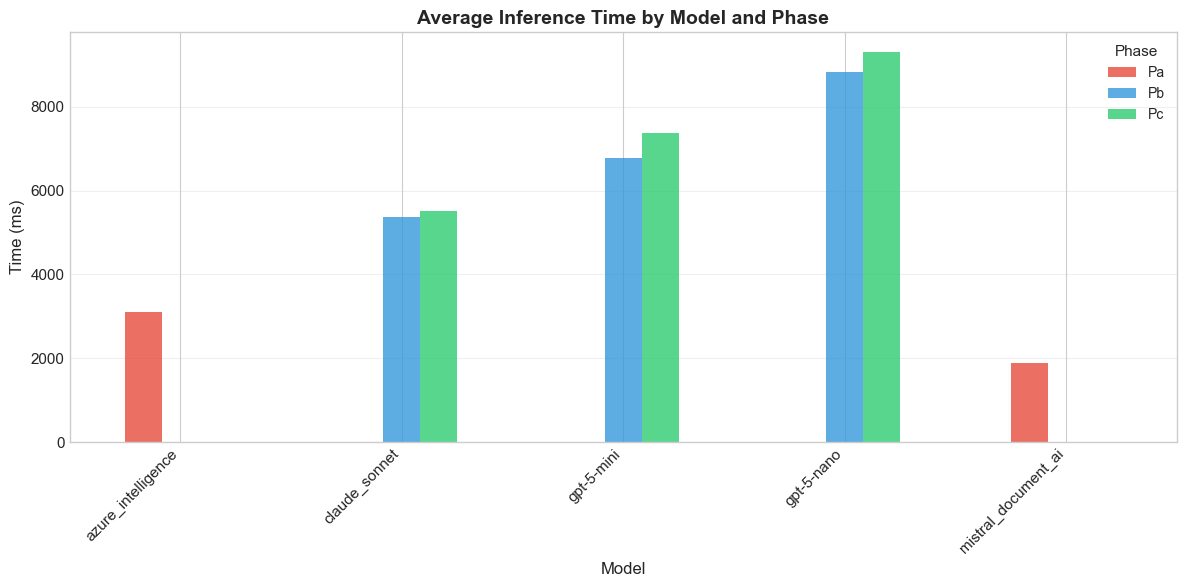

In [ ]:
# Analyze inference times across models and phases
inference_data = []

for phase, df in phase_dfs.items():
    time_cols = [col for col in df.columns if col.startswith('inference_time_ms_')]
    
    for time_col in time_cols:
        model = time_col.replace('inference_time_ms_', '')
        
        mean_time = df[time_col].mean()
        median_time = df[time_col].median()
        
        inference_data.append({
            'Phase': phase,
            'Model': model,
            'Mean Time (ms)': mean_time,
            'Median Time (ms)': median_time
        })

if inference_data:
    inference_df = pd.DataFrame(inference_data)
    
    print("\nInference Time Summary:")
    print("="*100)
    display(inference_df.sort_values(['Phase', 'Mean Time (ms)']))
    
    # Visualization
    fig, ax = plt.subplots(figsize=(12, 6))
    
    pivot_time = inference_df.pivot(index='Model', columns='Phase', values='Mean Time (ms)')
    pivot_time.plot(kind='bar', ax=ax, color=['#e74c3c', '#3498db', '#2ecc71'], alpha=0.8)
    
    ax.set_title('Average Inference Time by Model and Phase', fontsize=14, fontweight='bold')
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel('Time (ms)', fontsize=12)
    ax.legend(title='Phase', title_fontsize=11, fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
else:
    print("No inference time data available")

## 5. LLM Query Section

This section is a placeholder for analyzing the notebook outputs using an LLM.

### Key Questions to Investigate:

1. **Performance Comparison:**
   - Which model performs best overall for handwriting recognition?
   - How do OCR models (Pa) compare to VLMs (Pb, Pc)?
   - What is the impact of task-aware prompting (Pc vs Pb)?

2. **Metric Insights:**
   - Is there a strong correlation between CER and WER?
   - Do models with low CER/WER also have high cosine similarity?
   - Are there models that excel at one metric but not others?

3. **Error Patterns:**
   - What types of handwriting cause the most errors?
   - Do models struggle more with cursive or print text?
   - Are there common character substitution patterns?

4. **Speed vs Accuracy:**
   - What is the trade-off between inference time and accuracy?
   - Which model offers the best balance?

5. **Recommendations:**
   - Which model should be used for production handwriting OCR?
   - Are specialized OCR models still necessary, or can VLMs replace them?
   - What improvements could be made to prompting strategies?

## 6. Save Embeddings Cache

Save any newly computed embeddings to disk for faster future runs.

In [ ]:
# Save any newly computed embeddings to disk for future use
if embedding_manager.modified_phases:
    print("💾 Saving newly computed embeddings...")
    saved_files = embedding_manager.save_new_embeddings()
    for f in saved_files:
        print(f"   ✅ Saved: {f}")
    print(f"\n📁 Embeddings saved to {EMBEDDINGS_DIR.resolve()}")
    print("   Next run will load these embeddings from cache (much faster!)")
else:
    print("✨ All embeddings were loaded from cache - no new embeddings to save.")

✨ All embeddings were loaded from cache - no new embeddings to save.


## Conclusion

This notebook provides a comprehensive analysis of handwriting recognition performance across OCR and VLM models.

**Key Deliverables:**
- Quantitative metrics (CER, WER, Cosine Similarity) for all models
- Visual comparisons across phases and models
- Error analysis identifying strengths and weaknesses
- Inference time benchmarks

**Next Steps:**
- Use LLM to generate natural language insights
- Identify specific handwriting styles that cause issues
- Recommend optimal model selection strategy